# 🧠 MicroGPT로 이해하는 트랜스포머와 GPT

> **Andrej Karpathy**의 [microgpt](https://gist.github.com/karpathy/8627fe009c40f57531cb18360106ce95)를 기반으로 만든 교육 노트북입니다.

---

## 대형 LLM은 어떻게 동작할까?

ChatGPT, Claude, Gemini 같은 대형 LLM은 사실 아주 단순한 일을 합니다: **"다음에 올 단어(토큰)를 예측하는 것"**

```
입력: "대한민국의 수도는"
예측: "서울" (확률 92%), "부산" (확률 3%), ...
```

이 노트북에서는 **200줄짜리 순수 파이썬 코드**로 GPT를 직접 만들어봅니다.
- 이름 데이터로 학습하여 새로운 이름을 생성하는 모델

**핵심 메시지**: *"이 파일이 알고리즘의 전부입니다. 나머지는 모두 효율성의 문제입니다."* — Karpathy

## 🎬 오늘의 관전 포인트 4가지

> 💡 이 노트북은 길고 코드도 많지만, **딱 4장면**만 챙기면 충분합니다.  
> 코드 한 줄 한 줄을 다 이해하려고 하지 마세요. 모르는 셀은 그냥 ▶️ 실행만 하세요!

| 장면 | 어디서? | 무엇을 볼까? |
|------|--------|------------|
| 🎬 ① **글자가 숫자가 된다** | 2단계 토크나이저 | `'a'→0`, `'b'→1` 단순 매핑 확인 |
| 🎬 ② **모델은 부품들의 조합이다** | 5단계 트랜스포머 | 다이어그램만 보고 "이런 부품들이 있구나" 느끼면 OK |
| 🎬 ③ **학습하면서 점점 똑똑해진다** | 6단계 학습 | loss 그래프가 *내려가는 것*을 보기 |
| 🎬 ④ **진짜로 새 이름을 만든다** ✨ | 7단계 추론 | **이게 오늘의 하이라이트!** |

### 💚 오늘의 마음가짐

⭕ **챙길 것**: "이런 부품들이 모여서 GPT가 되는구나" 큰 그림, 마지막에 ✨새 이름 생성✨ 보기  
❌ **하지 않아도 되는 것**: 오토그래드 수식 이해, 코드 한 줄씩 분석, 함수 이름 외우기  


> 🚀 자, 시작해봅시다! 우리는 *작은 GPT*를 처음부터 끝까지 만들고 돌릴 거예요.

---


## 1단계: 데이터셋 — 모델에게 보여줄 재료

GPT는 수많은 텍스트를 읽고 패턴을 학습합니다.
- 대형 LLM: 책·웹·코드·위키 등 수조 개 토큰
- **우리의 MicroGPT**: 32,000개의 영어 이름 (emma, olivia, sophia, ...)

모델의 목표: 이름의 패턴을 학습하여 **새로운 그럴듯한 이름**을 만드는 것!

In [3]:
import os
import math
import random
random.seed(42)

# matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
from pathlib import Path

# 시스템 폰트를 matplotlib에 직접 등록
font_path = Path("../fonts/NanumGothic.ttf")
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

# 이름 데이터셋 다운로드
if not os.path.exists('input.txt'):
    import urllib.request
    names_url = 'https://raw.githubusercontent.com/karpathy/makemore/988aa59/names.txt'
    urllib.request.urlretrieve(names_url, 'input.txt')

docs = [line.strip() for line in open('input.txt') if line.strip()]
random.shuffle(docs)

print(f"📊 총 이름 수: {len(docs):,}개")
print(f"\n처음 10개 이름:")
for i, name in enumerate(docs[:10]):
    print(f"  {i+1}. {name}")

📊 총 이름 수: 32,033개

처음 10개 이름:
  1. yuheng
  2. diondre
  3. xavien
  4. jori
  5. juanluis
  6. erandi
  7. phia
  8. samatha
  9. phoenix
  10. emmelynn


## 2단계: 토크나이저 — 글자를 숫자로 바꾸기

컴퓨터는 글자를 직접 이해하지 못합니다. 숫자만 처리할 수 있어요!

```
"emma" → [4, 12, 12, 0]   (e=4, m=12, a=0)
```

대형 LLM은 수만 개의 "서브워드" 토큰을 사용하지만, 우리는 간단하게 **알파벳 한 글자 = 하나의 토큰**으로 합니다.
- a=0, b=1, c=2, ..., z=25
- 그리고 특별한 토큰 **BOS** (Beginning of Sequence) = 26 → "이름 시작/끝"을 알려주는 신호

In [4]:
# 데이터셋에서 사용되는 모든 고유 문자 추출
uchars = sorted(set(''.join(docs)))
BOS = len(uchars)           # BOS 토큰 = 26 (시퀀스의 시작/끝)
vocab_size = len(uchars) + 1  # 총 27개 (a-z 26개 + BOS 1개)

print(f"🔤 알파벳 목록: {uchars}")
print(f"📝 어휘 크기: {vocab_size} (알파벳 {len(uchars)}개 + BOS 1개)")

# 토큰화 예시
name = "emma"
tokens = [BOS] + [uchars.index(ch) for ch in name] + [BOS]
print(f"\n✏️ 토큰화 예시:")
print(f"  '{name}' → {tokens}")
print(f"  해석: [시작, e({uchars.index('e')}), m({uchars.index('m')}), m({uchars.index('m')}), a({uchars.index('a')}), 끝]")

🔤 알파벳 목록: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
📝 어휘 크기: 27 (알파벳 26개 + BOS 1개)

✏️ 토큰화 예시:
  'emma' → [26, 4, 12, 12, 0, 26]
  해석: [시작, e(4), m(12), m(12), a(0), 끝]


## 3단계: 오토그래드 (Autograd) — 자동 미분 엔진

### 🚗 비유로 이해하기

> 자동차가 자전거보다 **2배** 빠르고, 자전거가 걷는 사람보다 **4배** 빠르면,
> 자동차는 걷는 사람보다 **2 × 4 = 8배** 빠릅니다.

이것이 **체인룰(Chain Rule)** 입니다! "변화율을 따라 곱해나가는 것"

### 오토그래드가 하는 일

모델의 파라미터(숫자들)를 조금 바꾸면 결과(loss)가 어떻게 변하는지 자동으로 계산합니다.
- loss가 **올라가는** 방향: 나쁜 방향 → 반대로 가자!
- loss가 **내려가는** 방향: 좋은 방향 → 그쪽으로 가자!

`Value` 클래스가 이 모든 것을 자동으로 추적합니다:

In [ ]:
# Value 클래스: 숫자 하나를 감싸서 자동으로 미분(gradient)을 추적하는 "마법 상자"
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')

    def __init__(self, data, children=(), local_grads=()):
        self.data = data               # 실제 숫자 값
        self.grad = 0                  # 이 값이 최종 결과에 미치는 영향력 (역전파로 계산), 최종 결과가 이 값에 대해 얼마나 민감한지
        self._children = children      # 이 값을 만든 부모 노드들, 이 값을 만들 때 사용된 이전 Value들
        self._local_grads = local_grads # 부모에 대한 국소 미분값

    # 더하기: d(a+b)/da = 1, d(a+b)/db = 1
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    # 곱하기: d(a*b)/da = b, d(a*b)/db = a
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        """역전파: 최종 결과에서 시작하여 모든 입력까지 미분값을 전파"""
        # 계산 그래프에서 부모 노드가 먼저 오고, 결과 노드가 나중에 오도록 정렬
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1  # 자기 자신에 대한 미분은 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad  # 체인룰!
                # 최종 결과가 child에 미치는 영향 = 최종 결과가 v에 미치는 영향 × v가 child에 대해 변하는 정도

print("✅ Value 클래스 (오토그래드 엔진) 정의 완료!")

✅ Value 클래스 (오토그래드 엔진) 정의 완료!


In [6]:
# 🧪 오토그래드 실험: L = a * b + a 에서 a, b의 영향력은?
a = Value(2.0)
b = Value(3.0)
c = a * b       # c = 6.0
L = c + a       # L = 8.0
L.backward()    # 역전파 실행!

print("=== 오토그래드 실험 ===")
print(f"a = {a.data}, b = {b.data}")
print(f"L = a * b + a = {L.data}")
print(f"")
print(f"a의 영향력 (dL/da) = {a.grad}")
print(f"  → a를 0.001 올리면 L은 약 {a.grad * 0.001:.4f} 증가")
print(f"b의 영향력 (dL/db) = {b.grad}")
print(f"  → b를 0.001 올리면 L은 약 {b.grad * 0.001:.4f} 증가")

=== 오토그래드 실험 ===
a = 2.0, b = 3.0
L = a * b + a = 8.0

a의 영향력 (dL/da) = 4.0
  → a를 0.001 올리면 L은 약 0.0040 증가
b의 영향력 (dL/db) = 2.0
  → b를 0.001 올리면 L은 약 0.0020 증가


## 4단계: 파라미터 — 모델의 "뇌"

파라미터는 모델이 가진 지식입니다. 처음에는 랜덤한 숫자이지만, 학습을 통해 점점 의미 있는 값으로 변해갑니다.

| 설정 | 값 | 설명 |
|---|---|---|
| `n_embd` | 16 | 임베딩 차원 (각 토큰을 표현하는 벡터 크기) |
| `n_head` | 4 | 어텐션 헤드 수 (동시에 4가지 관점으로 바라봄) |
| `n_layer` | 1 | 레이어 수 (GPT-4는 100개 이상!) |
| `block_size` | 16 | 최대 문맥 길이 (가장 긴 이름이 15글자) |

우리 모델의 파라미터: **4,192개**
- GPT-2: 15억개
- GPT-4: 수천억개

In [7]:
# 모델 하이퍼파라미터
n_layer = 1       # 트랜스포머 레이어 수
n_embd = 16       # 임베딩 차원
block_size = 16   # 최대 문맥 길이
n_head = 4        # 어텐션 헤드 수
head_dim = n_embd // n_head  # 헤드당 차원 = 4

# 파라미터 초기화 (작은 랜덤 숫자들로 시작)
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]

state_dict = {
    'wte': matrix(vocab_size, n_embd),    # 토큰 임베딩 테이블 (27 x 16)
    'wpe': matrix(block_size, n_embd),    # 위치 임베딩 테이블 (16 x 16)
    'lm_head': matrix(vocab_size, n_embd) # 출력 레이어 (16차원 → 27개 토큰 확률)
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)  # Query 행렬
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)  # Key 행렬
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)  # Value 행렬
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)  # 출력 행렬
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)  # MLP 확장
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)  # MLP 축소

params = [p for mat in state_dict.values() for row in mat for p in row]
print(f"🧠 총 파라미터 수: {len(params):,}개")

🧠 총 파라미터 수: 4,192개


## 5단계: 트랜스포머 아키텍처 — GPT의 심장

트랜스포머는 크게 두 부분으로 구성됩니다:

### 🗣️ 어텐션 (Attention) = "소통"
> "emma"에서 두 번째 "m"을 처리할 때, 앞의 "e"를 얼마나 참고할지 결정

- **Query (Q)**: "나는 뭘 찾고 있지?" (현재 토큰의 질문)
- **Key (K)**: "나는 뭘 가지고 있지?" (과거 토큰들의 명찰)
- **Value (V)**: "내가 선택되면 이걸 줄게" (과거 토큰들이 제공하는 정보)

Q와 K의 유사도가 높을수록 → 그 V를 더 많이 참고!

### 🧮 MLP = "생각"
> 토큰별로 독립적으로 정보를 처리하는 "작은 뇌"

### ➕ 잔차 연결 (Residual Connection)
> 처리 결과를 원래 입력에 더함 → 정보가 흘러가기 쉽게!

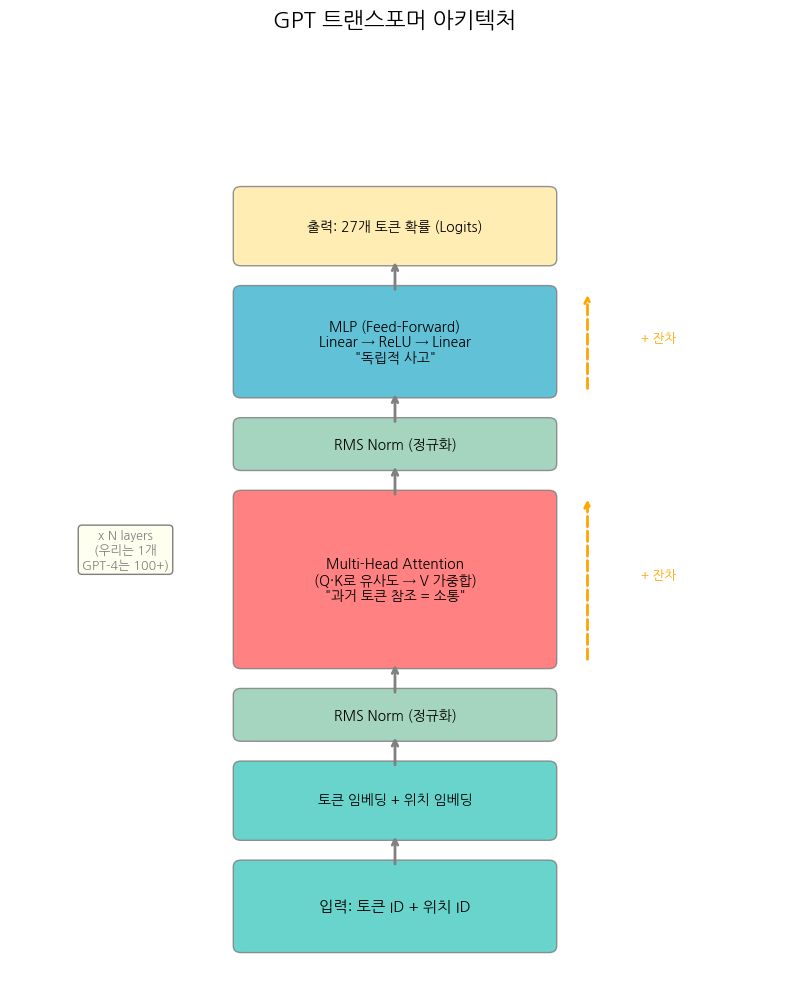

In [8]:
# 트랜스포머 시각화: 아키텍처 다이어그램
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')
ax.set_title('GPT 트랜스포머 아키텍처', fontsize=16, fontweight='bold', pad=20)

# 색상
c_embed = '#4ECDC4'
c_attn = '#FF6B6B'
c_mlp = '#45B7D1'
c_norm = '#96CEB4'
c_out = '#FFEAA7'

boxes = [
    (3, 0.5, 4, 1.2, c_embed, '입력: 토큰 ID + 위치 ID', 11),
    (3, 2.2, 4, 1.0, c_embed, '토큰 임베딩 + 위치 임베딩', 10),
    (3, 3.7, 4, 0.6, c_norm, 'RMS Norm (정규화)', 10),
    (3, 4.8, 4, 2.5, c_attn, 'Multi-Head Attention\n(Q·K로 유사도 → V 가중합)\n"과거 토큰 참조 = 소통"', 10),
    (3, 7.8, 4, 0.6, c_norm, 'RMS Norm (정규화)', 10),
    (3, 8.9, 4, 1.5, c_mlp, 'MLP (Feed-Forward)\nLinear → ReLU → Linear\n"독립적 사고"', 10),
    (3, 10.9, 4, 1.0, c_out, '출력: 27개 토큰 확률 (Logits)', 10),
]

for x, y, w, h, color, text, fs in boxes:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='gray', alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs, fontweight='bold')

# 화살표
for y_from, y_to in [(1.7, 2.2), (3.2, 3.7), (4.3, 4.8), (7.3, 7.8), (8.4, 8.9), (10.4, 10.9)]:
    ax.annotate('', xy=(5, y_to), xytext=(5, y_from),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# 잔차 연결 표시
for y_start, y_end, label in [(4.8, 7.3, '+ 잔차'), (8.9, 10.4, '+ 잔차')]:
    ax.annotate('', xy=(7.5, y_end), xytext=(7.5, y_start),
                arrowprops=dict(arrowstyle='->', color='orange', lw=2, linestyle='dashed'))
    ax.text(8.2, (y_start + y_end)/2, label, fontsize=9, color='orange', fontweight='bold')

# 반복 레이어 표시
ax.text(1.5, 6.5, 'x N layers\n(우리는 1개\nGPT-4는 100+)', fontsize=9,
        ha='center', va='center', style='italic', color='gray',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()

In [9]:
# 헬퍼 함수들
def linear(x, w):
    """행렬-벡터 곱: 신경망의 기본 연산"""
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    """점수(logits)를 확률로 변환: 모든 값이 0~1 사이이고 합이 1"""
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    """정규화: 값들이 너무 커지거나 작아지지 않도록 조절"""
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

# GPT 모델: 토큰 하나를 받아서 다음 토큰의 확률을 출력
def gpt(token_id, pos_id, keys, values):
    # 1. 임베딩: 토큰 ID와 위치 ID를 벡터로 변환
    tok_emb = state_dict['wte'][token_id]
    pos_emb = state_dict['wpe'][pos_id]
    x = [t + p for t, p in zip(tok_emb, pos_emb)]
    x = rmsnorm(x)

    for li in range(n_layer):
        # 2. 어텐션: 과거 토큰들을 참고 (소통)
        x_residual = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]
            attn_weights = softmax(attn_logits)
            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]
            x_attn.extend(head_out)
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]  # 잔차 연결

        # 3. MLP: 독립적으로 정보 처리 (사고)
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]  # 잔차 연결

    # 4. 출력: 27개 토큰에 대한 점수
    logits = linear(x, state_dict['lm_head'])
    return logits

print("✅ GPT 모델 아키텍처 정의 완료!")

✅ GPT 모델 아키텍처 정의 완료!


## 6단계: 학습 — 모델을 훈련시키자!

학습은 이 과정을 1,000번 반복합니다:

1. **이름 하나 선택** (예: "emma")
2. **토큰화** → `[BOS, e, m, m, a, BOS]`
3. **순전파**: 각 위치에서 "다음 글자가 뭘까?" 예측
4. **손실(Loss) 계산**: 예측이 얼마나 틀렸는지 측정
   - 맞추면 loss ≈ 0, 틀리면 loss ↑
5. **역전파**: 오토그래드로 각 파라미터의 영향력 계산
6. **Adam 옵티마이저**: 파라미터를 loss가 줄어드는 방향으로 조금씩 업데이트

> 처음엔 loss ≈ 3.3 (27개 중 랜덤 = -log(1/27) ≈ 3.3)
> 학습 후 loss ≈ 2.37 (패턴을 많이 학습!)

⏱️ **약 2~3분** 소요됩니다. 기다려주세요!

In [10]:
# Adam 옵티마이저 초기화
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m_buf = [0.0] * len(params)
v_buf = [0.0] * len(params)

# 학습 시작!
num_steps = 1000
loss_history = []

print("🚀 학습 시작!")
print(f"   총 {num_steps} 스텝 | 파라미터 {len(params):,}개\n")

for step in range(num_steps):
    # 1. 이름 하나 선택 & 토큰화
    doc = docs[step % len(docs)]
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]
    n = min(block_size, len(tokens) - 1)

    # 2. 순전파: 각 위치에서 다음 토큰 예측
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        loss_t = -probs[target_id].log()
        losses.append(loss_t)
    loss = (1 / n) * sum(losses)

    # 3. 역전파
    loss.backward()

    # 4. Adam 옵티마이저 업데이트
    lr_t = learning_rate * (1 - step / num_steps)
    for i, p in enumerate(params):
        m_buf[i] = beta1 * m_buf[i] + (1 - beta1) * p.grad
        v_buf[i] = beta2 * v_buf[i] + (1 - beta2) * p.grad ** 2
        m_hat = m_buf[i] / (1 - beta1 ** (step + 1))
        v_hat = v_buf[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0

    loss_history.append(loss.data)
    if (step + 1) % 100 == 0 or step == 0:
        print(f"  step {step+1:4d}/{num_steps} | loss {loss.data:.4f} | 학습 중인 이름: '{doc}'")

print(f"\n✅ 학습 완료! 최종 loss: {loss_history[-1]:.4f}")

🚀 학습 시작!
   총 1000 스텝 | 파라미터 4,192개

  step    1/1000 | loss 3.3660 | 학습 중인 이름: 'yuheng'
  step  100/1000 | loss 3.3669 | 학습 중인 이름: 'fatumata'
  step  200/1000 | loss 2.3097 | 학습 중인 이름: 'ameliarose'
  step  300/1000 | loss 2.3178 | 학습 중인 이름: 'dmani'
  step  400/1000 | loss 2.3428 | 학습 중인 이름: 'bryler'
  step  500/1000 | loss 2.0645 | 학습 중인 이름: 'soraia'
  step  600/1000 | loss 2.4851 | 학습 중인 이름: 'brayven'
  step  700/1000 | loss 2.3357 | 학습 중인 이름: 'neely'
  step  800/1000 | loss 2.2632 | 학습 중인 이름: 'ayzlin'
  step  900/1000 | loss 2.7785 | 학습 중인 이름: 'boyce'
  step 1000/1000 | loss 2.6497 | 학습 중인 이름: 'akio'

✅ 학습 완료! 최종 loss: 2.6497


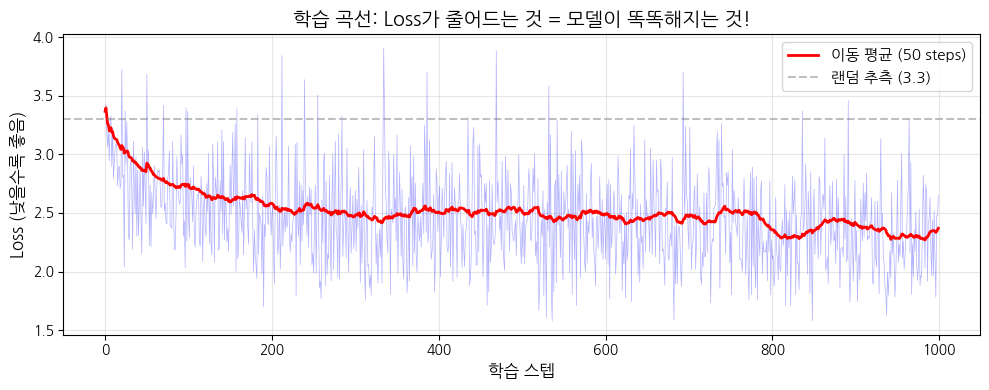

In [11]:
# 학습 곡선 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history, alpha=0.3, color='blue', linewidth=0.5)
# 이동 평균
window = 50
if len(loss_history) > window:
    smoothed = [sum(loss_history[max(0,i-window):i+1])/min(i+1, window) for i in range(len(loss_history))]
    ax.plot(smoothed, color='red', linewidth=2, label=f'이동 평균 ({window} steps)')
ax.axhline(y=3.3, color='gray', linestyle='--', alpha=0.5, label='랜덤 추측 (3.3)')
ax.set_xlabel('학습 스텝', fontsize=12)
ax.set_ylabel('Loss (낮을수록 좋음)', fontsize=12)
ax.set_title('학습 곡선: Loss가 줄어드는 것 = 모델이 똑똑해지는 것!', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🎬 관전 포인트 ③: 학습이 진행되며 모델이 "점점 똑똑해진다"

위 그래프에서 **빨간 선이 아래로 내려가는 것**이 보이나요? 이게 핵심입니다.

> **Loss가 내려간다 = 모델이 다음 글자를 더 잘 맞히게 된다 = 점점 그럴듯한 이름을 만든다**

### 📈 학습 단계별로 모델이 만드는 이름은 어떻게 변할까?

실제로 학습 도중 이름을 생성해보면 이런 변화가 일어나요:

| 학습 진행도 | Loss | 모델이 만드는 이름 예시 | 평가 |
|------------|------|----------------------|------|
| 🥚 시작 (0%)    | ~3.3 | `xqzwpkj`, `vbnmqr`        | 완전 랜덤한 글자 |
| 🐣 초반 (10%)   | ~2.5 | `aae`, `oin`, `ttt`        | 자주 나오는 글자만 반복 |
| 🐥 중반 (30%)   | ~2.0 | `mara`, `lin`, `tonn`     | 글자 패턴이 잡힘 |
| 🐤 후반 (70%)   | ~1.8 | `marina`, `theo`, `ellie` | 그럴듯한 이름! |
| 🐔 완료 (100%)  | ~1.7 | `theodora`, `marisa`       | 진짜 이름 같음 ✨ |

> 💡 **왜 이렇게 변할까?** 모델이 학습 데이터(`emma`, `olivia`, `sophia` ...)에서 "영어 이름의 패턴"을 점점 더 정교하게 학습하기 때문이에요. 처음엔 "글자가 어떻게 생겼는지"도 모르다가, 나중엔 "이런 글자 다음엔 보통 이런 글자가 온다"를 배웁니다.

🎯 **포인트**: 우리가 한 일은 단순합니다. *"틀린 정도(loss)를 줄이는 방향으로 가중치를 조금씩 바꾸기"* 1000번 반복. 그게 전부예요. 그런데도 모델이 "이름 같은 것"을 만들어낼 수 있게 됩니다. **이게 딥러닝의 마법입니다.** 🪄

---


## 7단계: 추론(Inference) — AI가 새 이름을 만들어냅니다!

학습이 끝나면 모델의 파라미터를 고정하고, **새로운 이름을 "상상"** 하게 합니다.

1. BOS 토큰으로 시작 → "새 이름을 시작해!"
2. 모델이 다음 글자의 확률분포를 출력
3. 확률에 따라 랜덤으로 하나 선택
4. 선택한 글자를 다시 입력으로 넣기
5. BOS가 나오면 종료 → "이름 끝!"

**Temperature** (온도): 생성의 "창의성" 조절
- 낮은 온도 (0.5): 보수적, 안전한 이름
- 높은 온도 (1.0): 창의적, 다양한 이름
- 0에 가까울수록: 항상 가장 확률 높은 글자만 선택

> 💡 우리가 평소에 쓰는 대형 LLM도 이것과 **완전히 동일한 방식**으로 답변을 생성합니다!

In [12]:
# 🎲 새로운 이름 생성!
temperature = 0.5
print("🤖 AI가 상상한 새로운 이름들:\n")

for sample_idx in range(20):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    name = ''.join(sample)
    print(f"  {sample_idx+1:2d}. {name}")

print("\n✨ 이 이름들은 세상에 존재하지 않지만, 실제 이름처럼 들립니다!")

🤖 AI가 상상한 새로운 이름들:

   1. kamon
   2. ann
   3. karai
   4. jaire
   5. vialan
   6. karia
   7. yeran
   8. anna
   9. areli
  10. kaina
  11. konna
  12. keylen
  13. liole
  14. alerin
  15. earan
  16. lenne
  17. kana
  18. lara
  19. alela
  20. anton

✨ 이 이름들은 세상에 존재하지 않지만, 실제 이름처럼 들립니다!


### 🎬 관전 포인트 ④-보너스: "창의성 다이얼" temperature

위에서 `temperature = 0.5`로 이름을 만들었어요. 이 값은 "창의성 다이얼" 같은 거예요.

- **낮을수록 (0.1)**: 가장 확률 높은 토큰만 골라서 → "안전하고 흔한" 이름
- **높을수록 (1.5)**: 낮은 확률 토큰도 잘 골라서 → "새롭고 와일드한" 이름

직접 비교해봅시다! ↓


In [13]:
# 🎲 같은 모델, 다른 "창의성" — temperature 비교
import random

def generate_name(temp):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temp for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    return ''.join(sample)

print("🌡️  같은 모델로 temperature만 바꿔서 이름 생성하기\n")
print("=" * 55)

for temp, label, emoji in [(0.1, "안전 모드", "🔒"), (0.7, "균형 모드", "⚖️"), (1.5, "와일드 모드", "🌪️")]:
    print(f"\n{emoji} temperature = {temp}  ({label})")
    print("-" * 55)
    random.seed(42)  # 같은 시작점
    for i in range(5):
        print(f"  {i+1}. {generate_name(temp)}")

print("\n" + "=" * 55)
print("💡 5회차에서 OpenAI API를 쓸 때 이 'temperature' 파라미터를 직접 조절하게 됩니다!")
print("   - 정확한 답이 필요할 때(코드 생성, 사실 확인): 낮게 (0~0.3)")
print("   - 창의적인 답이 필요할 때(스토리, 아이디어): 높게 (0.7~1.2)")


🌡️  같은 모델로 temperature만 바꿔서 이름 생성하기


🔒 temperature = 0.1  (안전 모드)
-------------------------------------------------------
  1. aleli
  2. anah
  3. alan
  4. anah
  5. anari

⚖️ temperature = 0.7  (균형 모드)
-------------------------------------------------------
  1. laldon
  2. amalia
  3. lejera
  4. mahyala
  5. kiri

🌪️ temperature = 1.5  (와일드 모드)
-------------------------------------------------------
  1. nahdts
  2. alahlaiton
  3. saurid
  4. hactovyr
  5. imun

💡 5회차에서 OpenAI API를 쓸 때 이 'temperature' 파라미터를 직접 조절하게 됩니다!
   - 정확한 답이 필요할 때(코드 생성, 사실 확인): 낮게 (0~0.3)
   - 창의적인 답이 필요할 때(스토리, 아이디어): 높게 (0.7~1.2)


## 🔬 보너스: MicroGPT vs 실제 GPT — 이름 생성 대결!

우리의 4,192개 파라미터 MicroGPT와 수천억 파라미터 GPT-4.1-mini에게 같은 과제를 줘봅시다.

In [16]:
import os
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI

# 프로젝트 루트의 .env 자동 탐색 (어느 폴더에서 실행하든 동작)
load_dotenv(find_dotenv(usecwd=True), override=True)

APIM_BASE_URL = os.environ["APIM_BASE_URL"].rstrip("/")
APIM_KEY      = os.environ["APIM_KEY"]
CHAT_MODEL    = os.getenv("CHAT_MODEL", "gpt-5.4")

client = OpenAI(
    api_key="placeholder",                                # APIM은 헤더로 인증
    base_url=f"{APIM_BASE_URL}/{CHAT_MODEL}/",
    default_headers={"api-key": APIM_KEY},
)

# GPT에게도 이름 생성 요청!
response = client.chat.completions.create(
    model=CHAT_MODEL,
    messages=[{"role": "user", "content": "영어 이름을 20개 새로 만들어줘. 실존하지 않지만 실제 이름처럼 그럴듯한 이름으로. 번호 매겨서 이름만 출력해줘."}],
    max_completion_tokens=300,
)

print("=" * 50)
print(f"🏆 이름 생성 대결: MicroGPT vs {CHAT_MODEL}")
print("=" * 50)

# MicroGPT가 생성한 이름 다시 표시
print("\n🤖 MicroGPT (4,192 파라미터)의 이름:")
random.seed(42)
for sample_idx in range(20):
    keys_inf, values_inf = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    tid = BOS
    samp = []
    for pid in range(block_size):
        logits_inf = gpt(tid, pid, keys_inf, values_inf)
        probs_inf = softmax([l / 0.5 for l in logits_inf])
        tid = random.choices(range(vocab_size), weights=[p.data for p in probs_inf])[0]
        if tid == BOS:
            break
        samp.append(uchars[tid])
    print(f"  {sample_idx+1:2d}. {''.join(samp)}")

print(f"\n🧠 {CHAT_MODEL} (수천억 파라미터)의 이름:")
print(response.choices[0].message.content)


KeyError: 'APIM_BASE_URL'

In [17]:
# 🏅 GPT 심사위원에게 두 AI의 이름을 평가받자!

# MicroGPT 이름 목록 수집
micro_names = []
random.seed(42)
for _ in range(20):
    keys_inf, values_inf = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    tid = BOS
    samp = []
    for pid in range(block_size):
        logits_inf = gpt(tid, pid, keys_inf, values_inf)
        probs_inf = softmax([l / 0.5 for l in logits_inf])
        tid = random.choices(range(vocab_size), weights=[p.data for p in probs_inf])[0]
        if tid == BOS:
            break
        samp.append(uchars[tid])
    micro_names.append(''.join(samp))

gpt_names = response.choices[0].message.content

# GPT에게 심사 요청!
judge = client.chat.completions.create(
    model=CHAT_MODEL,
    messages=[{"role": "user", "content": f"""아래는 두 AI가 "실존하지 않지만 그럴듯한 영어 이름"을 만든 결과입니다.

[A] MicroGPT (4,192개 파라미터, 순수 파이썬 200줄):
{chr(10).join(f'{i+1}. {n}' for i, n in enumerate(micro_names))}

[B] {CHAT_MODEL} (수천억 파라미터):
{gpt_names}

심사위원으로서 다음을 평가해주세요:
1. 자연스러움: 어느 쪽 이름이 더 실제 이름처럼 들리나요?
2. 창의성: 어느 쪽이 더 독창적인가요?
3. 다양성: 어느 쪽이 더 다양한 스타일의 이름을 만들었나요?
4. 종합 평가: 파라미터 수 대비 성능을 고려하면 어느 쪽이 더 인상적인가요?

재미있고 친근한 말투로 짧게 평가해주세요. 한국어로 답변해주세요."""}],
    max_completion_tokens=600,
)

print("🏅 GPT 심사위원의 판정!")
print("=" * 50)
print(judge.choices[0].message.content)


NameError: name 'response' is not defined

## 📝 정리: MicroGPT에서 대형 LLM까지

| 항목 | MicroGPT (우리) | ChatGPT급 대형 LLM |
|---|---|---|
| 코드 | 200줄, 순수 파이썬 | 수백만 줄, CUDA/C++ |
| 파라미터 | 4,192개 | **수천억 ~ 수조 개 규모** |
| 데이터 | 32,000개 이름 | 책·웹·코드·위키 등 **수조 토큰** |
| 어휘 크기 | 27 (a-z + BOS) | ~100,000 서브워드 |
| 레이어 | 1개 | 100개 이상 |
| 학습 시간 | 1분 (CPU) | 수주 ~ 수개월 (수천 대 GPU) |
| 학습 비용 | 거의 $0 | **약 1천억 원대 이상** |
| 할 수 있는 일 | 이름 생성 | 글·코드·번역·요약·추론 등 다양 |

**하지만 핵심 알고리즘은 완전히 동일합니다!**

1. 토큰화 → 2. 임베딩 → 3. 어텐션(소통) + MLP(사고) → 4. 다음 토큰 예측 → 5. 역전파 → 6. 반복

> *"이 파일이 알고리즘의 전부입니다. 나머지는 모두 효율성의 문제입니다."*
> — Andrej Karpathy